## Generate Images and Mask Tiles

In [ ]:
!pip install geotile
!pip install fiona
from geotile import GeoTile
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
PATH_TRAIN_x = r'/content/drive/MyDrive/Course Geoai/Before/Training/train.tif'
PATH_TRAIN_Y = r'/content/drive/MyDrive/Course Geoai/Before/Training/train.shp'
PATH_TEST_x = r'/content/drive/MyDrive/Course Geoai/Before/Testing/test.tif'
PATH_TEST_Y = r'/content/drive/MyDrive/Course Geoai/Before/Testing/test.shp'

In [ ]:
gt_train = GeoTile(PATH_TRAIN_x)
gt_train.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 1999,
 'height': 1999,
 'count': 3,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 48S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32748"]]'),
 'transform': Affine(0.14999999999998836, 0.0, 704949.0,
        0.0, -0.14999999999981364, 9272834.1)}

## Pemotongan Citra (Tiling)

In [ ]:
gt_train.generate_tiles(r'/content/drive/MyDrive/Course Geoai/After/train_x_tiles', prefix='train_')
gt_train.rasterization(PATH_TRAIN_Y, '/content/drive/MyDrive/Course Geoai/After/y_train.tif')
gt_train_y = GeoTile('/content/drive/MyDrive/Course Geoai/After/y_train.tif')
gt_train_y.generate_tiles(r'/content/drive/MyDrive/Course Geoai/After/train_y_tiles', prefix='train_')

In [ ]:
gt_test = GeoTile(PATH_TEST_x)
gt_test.generate_tiles(r'/content/drive/MyDrive/Course Geoai/After/test_x_tiles', prefix='test_')
gt_test.rasterization(PATH_TEST_Y, '/content/drive/MyDrive/Course Geoai/After/y_test.tif')
gt_test_y = GeoTile('/content/drive/MyDrive/Course Geoai/After/y_test.tif')
gt_test_y.generate_tiles(r'/content/drive/MyDrive/Course Geoai/After/test_y_tiles', prefix='test_')

## Generate Tiles dan Menyimpan dalam numpy

In [ ]:
gt_train.generate_tiles(save_tiles=False)
gt_train_y.generate_tiles(save_tiles=False)
gt_train.convert_nan_to_zero()

In [ ]:
gt_train.normalize_tiles()

In [ ]:
import numpy as np
gt_train.tile_data.min(), gt_train.tile_data.max()

(np.float32(0.0), np.float32(1.0))

In [ ]:
gt_train.save_numpy('/content/drive/MyDrive/Course Geoai/After//x_train.npy')
gt_train_y.save_numpy('/content/drive/MyDrive/Course Geoai/After//y_train.npy')

In [ ]:
gt_test.generate_tiles(save_tiles=False)
gt_test_y.generate_tiles(save_tiles=False)
gt_test.convert_nan_to_zero()
gt_test.normalize_tiles()
gt_test.save_numpy('/content/drive/MyDrive/Course Geoai/After/x_test.npy')
gt_test_y.save_numpy('/content/drive/MyDrive/Course Geoai/After/y_test.npy')

In [ ]:
x_train = np.load('/content/drive/MyDrive/Course Geoai/After/x_train.npy')
x_train.max(), x_train.min(), x_train.dtype, x_train.shape

(np.float32(1.0), np.float32(0.0), dtype('float32'), (256, 256, 256, 3))

In [ ]:
y_train = np.load('/content/drive/MyDrive/Course Geoai/After/y_train.npy')
y_train.max(), y_train.min(), y_train.dtype, y_train.shape

(np.int64(1), np.int64(0), dtype('int64'), (256, 256, 256, 1))

120


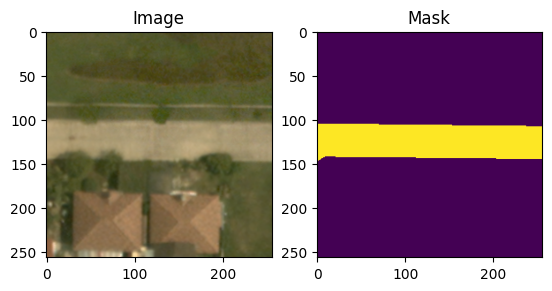

In [ ]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1,2)
img = np.random.randint(0, 256)
print (img)
ax1.imshow(x_train[img, :, :, :3])
ax2.imshow(y_train[img, :, :, 0])
ax1.set_title('Image')
ax2.set_title('Mask')
plt.show()